In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

In [20]:
# 1. 데이터 로드 및 전처리

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML/WISDM.csv', header=None)

df

,0,1,2,3,4,5,6
0,0,33,Jogging,4.910600e+13,-0.694638,12.680544,0.503953
1,1,33,Jogging,4.910610e+13,5.012288,11.264028,0.953424
2,2,33,Jogging,4.910610e+13,4.903325,10.882658,-0.081722
3,3,33,Jogging,4.910620e+13,-0.612916,18.496431,3.023717
4,4,33,Jogging,4.910630e+13,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...,...
1048570,1048571,7,Standing,2.091650e+14,-7.930000,5.430000,-0.990000
1048571,1048572,7,Standing,2.091660e+14,-7.970000,5.130000,-1.140000
1048572,1048573,7,Standing,2.091660e+14,-7.970000,5.220000,-1.380000
1048573,1048574,7,Standing,2.091660e+14,-7.930000,5.600000,-1.180000


In [21]:
df.shape

(1048575, 7)

In [22]:
# 결측치 홗인

df.isnull().values.any()

np.False_

In [24]:
# 2. 필터링할 활동 리스트 정의
target_activities = ['Jogging', 'Standing']

# 3. 2번 인덱스 열(3번째 열)의 값이 리스트에 포함된 행만 필터링
# .isin() 함수를 사용하면 target_activities에 포함된 모든 행을 선택합니다.
df = df[df[2].isin(target_activities)]

df

,0,1,2,3,4,5,6
0,0,33,Jogging,4.910600e+13,-0.694638,12.680544,0.503953
1,1,33,Jogging,4.910610e+13,5.012288,11.264028,0.953424
2,2,33,Jogging,4.910610e+13,4.903325,10.882658,-0.081722
3,3,33,Jogging,4.910620e+13,-0.612916,18.496431,3.023717
4,4,33,Jogging,4.910630e+13,-1.184970,12.108489,7.205164
...,...,...,...,...,...,...,...
1048570,1048571,7,Standing,2.091650e+14,-7.930000,5.430000,-0.990000
1048571,1048572,7,Standing,2.091660e+14,-7.970000,5.130000,-1.140000
1048572,1048573,7,Standing,2.091660e+14,-7.970000,5.220000,-1.380000
1048573,1048574,7,Standing,2.091660e+14,-7.930000,5.600000,-1.180000


In [26]:
# 3. 데이터 프레임 재구성 (센서 데이터 + Class)

data = df[[4, 5, 6]].copy()

data['Class'] = df[2].apply(lambda x: 0 if x == 'Standing' else 1)

In [27]:
# 4. 스케일링.
sensor_cols = [4, 5, 6]
scaler = MinMaxScaler()
data[sensor_cols] = scaler.fit_transform(data[sensor_cols])

In [28]:
print("--- 데이터 전처리 완료 (상위 5개) ---")
print(data.head())

--- 데이터 전처리 완료 (상위 5개) ---
          4         5         6  Class
0  0.478144  0.814390  0.515198      1
1  0.622404  0.778664  0.526603      1
2  0.619649  0.769046  0.500337      1
3  0.480209  0.961070  0.579135      1
4  0.465749  0.799962  0.685236      1


In [29]:
RANDOM_SEED = 42

# 1. 전체 데이터를 훈련(80%) / 테스트(20%) 세트로 분할
X_train, X_test = train_test_split(data, test_size=0.2, random_state=RANDOM_SEED)

# 2. 훈련 세트(X_train)에서 '정상'(Class == 0) 데이터만 남김
X_train = X_train[X_train.Class == 0]
X_train = X_train.drop(['Class'], axis=1) # Class 열 제거

# 3. 테스트 세트(X_test)는 라벨(y_test)과 데이터(X_test)로 분리
y_test = X_test['Class']
X_test = X_test.drop(['Class'], axis=1)

# 4. Keras 모델 입력을 위해 .values로 변환
X_train = X_train.values
X_test = X_test.values

print(f"\n정상(Standing) 훈련 데이터 형태: {X_train.shape}")
print(f"테스트 데이터 형태: {X_test.shape}")


정상(Standing) 훈련 데이터 형태: (35515, 3)
테스트 데이터 형태: (74105, 3)


In [31]:
# 1. 오토인코더 모델 정의
input_dim = X_train.shape[1] # 3 (센서 3개)
encoding_dim = 2 # 3 -> 2 -> 3 (간단한 AE)

input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer) # 3 -> 2
decoded = Dense(input_dim, activation='sigmoid')(encoded)     # 2 -> 3

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [32]:
# 2. 모델 학습 (오직 정상 데이터 'X_train'으로만 학습)
history = autoencoder.fit(X_train, X_train,
                          epochs=50,
                          batch_size=256,
                          shuffle=True,
                          validation_split = 0.1) # 훈련 데이터 중 10%를 검증용으로 사용

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0157 - val_loss: 0.0076
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0061 - val_loss: 0.0038
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0033 - val_loss: 0.0027
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0026 - val_loss: 0.0024
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0023 - val_loss: 0.0024
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023 - val_loss: 0.0023
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022 - val_loss: 0.0023
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

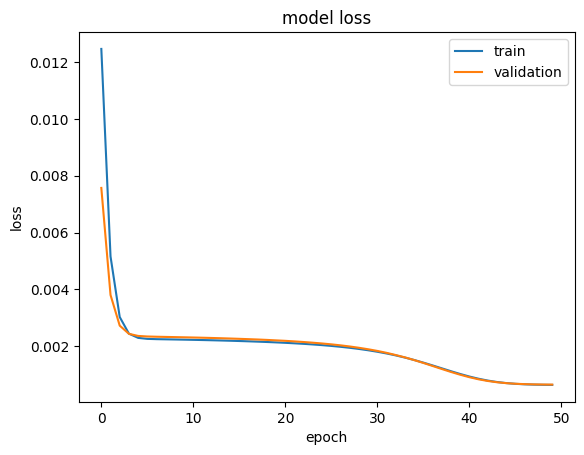

In [33]:
# 3. 학습 손실 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.show()

In [34]:
# X_test 값을 넣어서 Reconstruction Error 값을 얻고,
# 실제 레이블인 y_test와 데이터프레임으로 구성
predictions = autoencoder.predict(X_test)
mse = np.mean(np.power(X_test - predictions, 2), axis=1)

error_df = pd.DataFrame({'reconstruction_error': mse,
                        'true_class': y_test})

# 정상(0)과 비정상(1)의 재구성 오류 통계 확인
print(error_df.describe())

print("\n--- 클래스별 재구성 오류 (평균) ---")
print(error_df.groupby('true_class')['reconstruction_error'].mean())

2316/2316 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step
       reconstruction_error    true_class
count          7.410500e+04  74105.000000
mean           2.641692e-02      0.878119
std            3.116576e-02      0.327151
min            5.820009e-07      0.000000
25%            5.995654e-03      1.000000
50%            1.812578e-02      1.000000
75%            3.364816e-02      1.000000
max            2.490776e-01      1.000000

--- 클래스별 재구성 오류 (평균) ---
true_class
0    0.000634
1    0.029996
Name: reconstruction_error, dtype: float64


In [39]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. LABELS 정의 (WISDM 데이터에 맞게)
LABELS = ["Standing (Normal)", "Jogging (Anomaly)"]

In [40]:
# 2. Threshold 설정 (!!!반드시 수정하세요!!!)
#
# 이전 단계에서 확인한 'Standing'과 'Jogging'의
# 평균 MSE 값을 기준으로 중간값을 설정하세요.
# 예: Standing_mse = 0.01, Jogging_mse = 0.5 라면 -> threshold = 0.1
#
threshold = 0.01  # <-- (예시 값) 여기에 올바른 값을 넣어주세요.

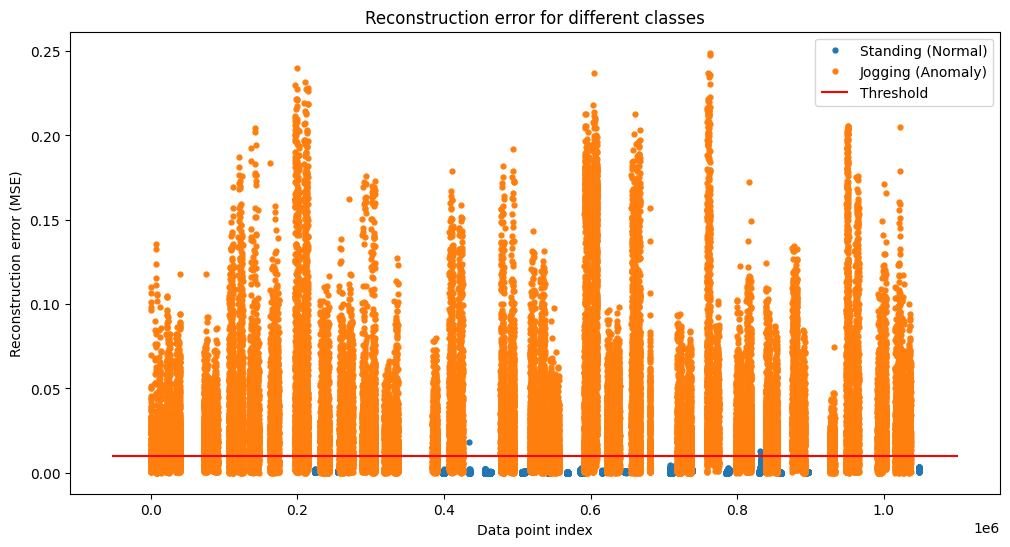

In [41]:
# 3. 재구성 오류(MSE) 산점도 (Scatter Plot)
groups = error_df.groupby('true_class')
fig, ax = plt.subplots(figsize=(12, 6))

for name, group in groups:
    ax.plot(group.index, group.reconstruction_error, marker='o', ms=3.5, linestyle='',
            label = LABELS[name]) # "Standing" 또는 "Jogging"으로 표시
ax.hlines(threshold, ax.get_xlim()[0], ax.get_xlim()[1], colors="r", zorder=100, label='Threshold')
ax.legend()
plt.title("Reconstruction error for different classes")
plt.ylabel("Reconstruction error (MSE)")
plt.xlabel("Data point index")
plt.show();

In [ ]:
# 4. 혼동 행렬 (Confusion Matrix)
# threshold를 기준으로 예측값(y_pred) 생성
y_pred = [1 if e > threshold else 0 for e in error_df.reconstruction_error.values]
conf_matrix = confusion_matrix(error_df.true_class, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d");
plt.title("Confusion Matrix")
plt.ylabel('True class (실제값)')
plt.xlabel('Predicted class (예측값)')
plt.show()

# 5. 분류 리포트 (Classification Report)
print("\n--- 분류 리포트 ---")
print(classification_report(error_df.true_class, y_pred, target_names=LABELS))